In [2]:
import pandas as pd

df = pd.read_csv('../data/student_productivity_dataset.csv')
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [3]:
# See shape and columns
df.shape
df.columns

# Basic stats
df.describe()

# Check for missing values
df.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

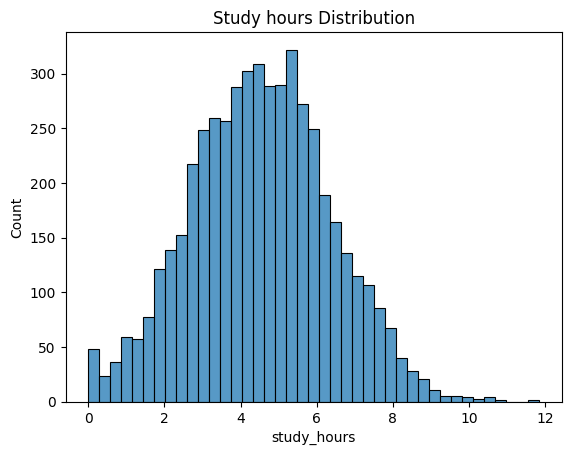

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['study_hours'])
plt.title('Study hours Distribution')
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.style.use('dark_background')
sns.set_palette("husl")

df = pd.read_csv('../data/student_productivity_dataset.csv')
print(df.shape)
df.head()


(5000, 21)


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


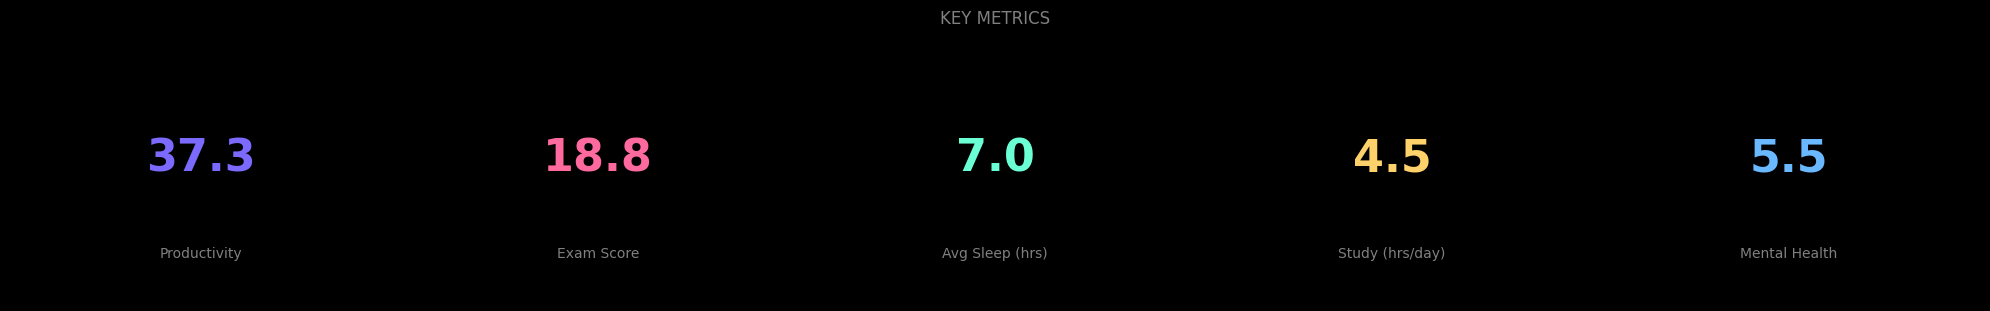

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
kpis = [
    ('productivity_score', 'Productivity', '#7c6aff'),
    ('exam_score', 'Exam Score', '#ff6a9e'),
    ('sleep_hours', 'Avg Sleep (hrs)', '#6affd4'),
    ('study_hours', 'Study (hrs/day)', '#ffd16a'),
    ('mental_health_score', 'Mental Health', '#6ab8ff'),
]
for ax, (col, label, color) in zip(axes, kpis):
    ax.set_facecolor('#12121f')
    ax.text(0.5, 0.6, f"{df[col].mean():.1f}", ha='center', va='center',
            fontsize=32, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=10, color='gray', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('KEY METRICS', fontsize=12, color='gray', y=1.02)
plt.tight_layout()
plt.show()

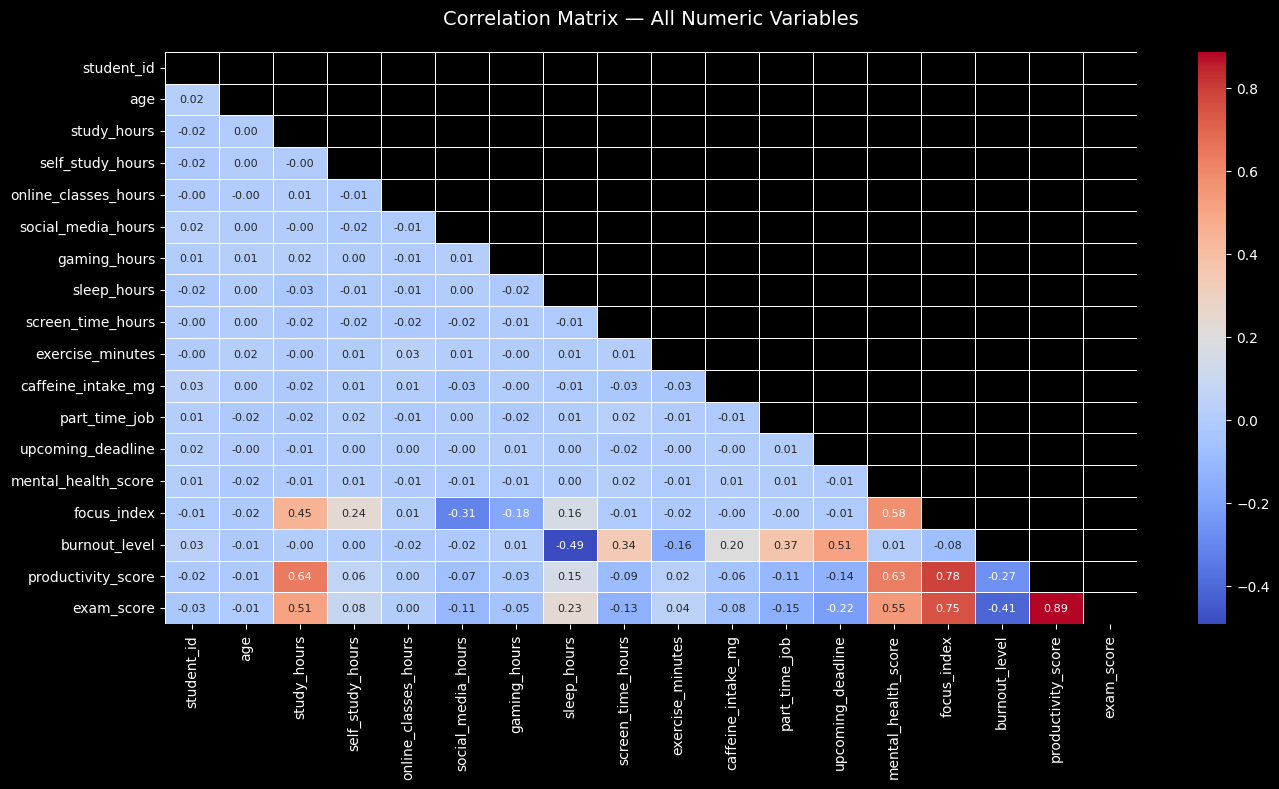

In [10]:
plt.figure(figsize=(14, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — All Numeric Variables', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

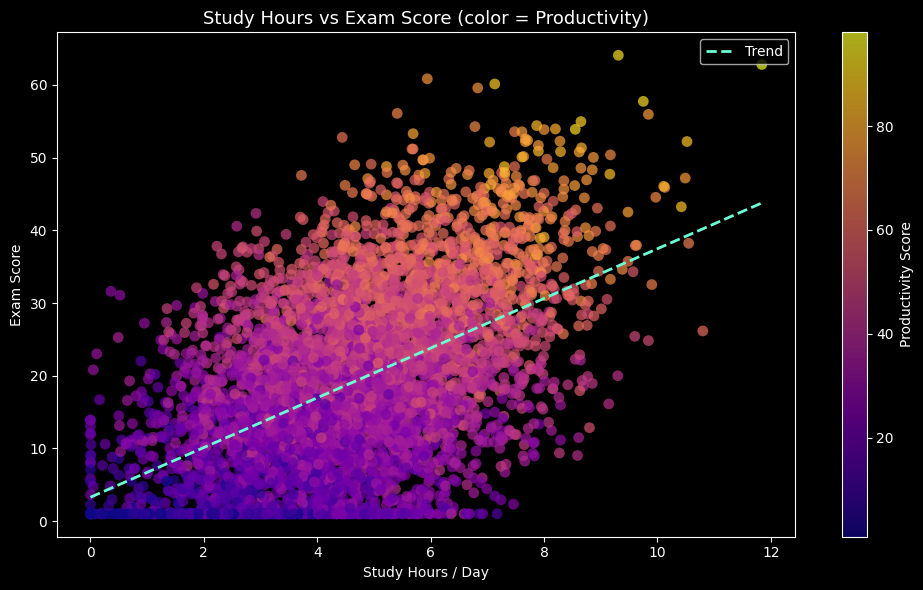

In [11]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['study_hours'], df['exam_score'],
                      c=df['productivity_score'], cmap='plasma',
                      alpha=0.7, s=60, edgecolors='none')
plt.colorbar(scatter, label='Productivity Score')
m, b = np.polyfit(df['study_hours'], df['exam_score'], 1)
x_line = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 100)
plt.plot(x_line, m*x_line + b, color='#6affd4', linewidth=2, linestyle='--', label='Trend')
plt.xlabel('Study Hours / Day')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score (color = Productivity)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

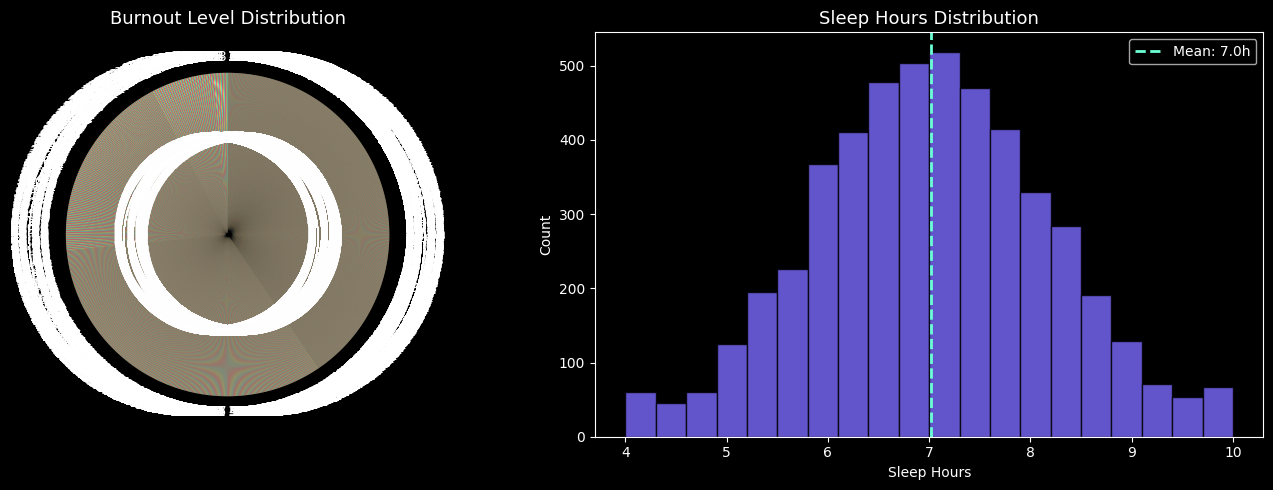

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Burnout pie
burnout_counts = df['burnout_level'].value_counts()
colors = ['#6affd4', '#ffd16a', '#ff6a9e']
axes[0].pie(burnout_counts, labels=burnout_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'color': 'white'})
axes[0].set_title('Burnout Level Distribution', fontsize=13)

# Sleep histogram
axes[1].hist(df['sleep_hours'], bins=20, color='#7c6aff', edgecolor='black', alpha=0.8)
axes[1].axvline(df['sleep_hours'].mean(), color='#6affd4', linestyle='--',
                linewidth=2, label=f"Mean: {df['sleep_hours'].mean():.1f}h")
axes[1].set_xlabel('Sleep Hours')
axes[1].set_ylabel('Count')
axes[1].set_title('Sleep Hours Distribution', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

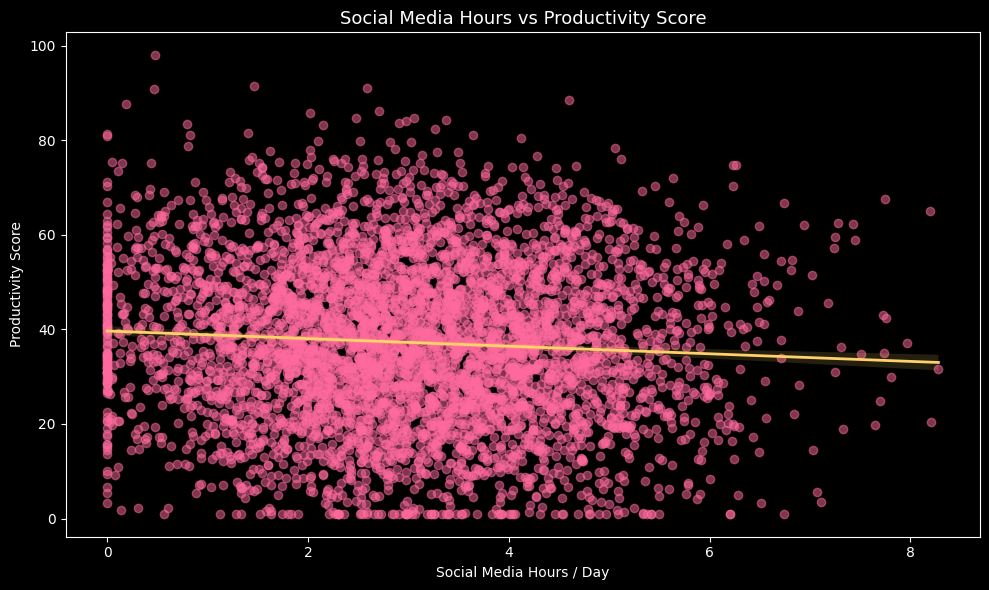

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(x='social_media_hours', y='productivity_score', data=df,
            scatter_kws={'alpha': 0.5, 'color': '#ff6a9e'},
            line_kws={'color': '#ffd16a', 'linewidth': 2})
plt.title('Social Media Hours vs Productivity Score', fontsize=13)
plt.xlabel('Social Media Hours / Day')
plt.ylabel('Productivity Score')
plt.tight_layout()
plt.show()

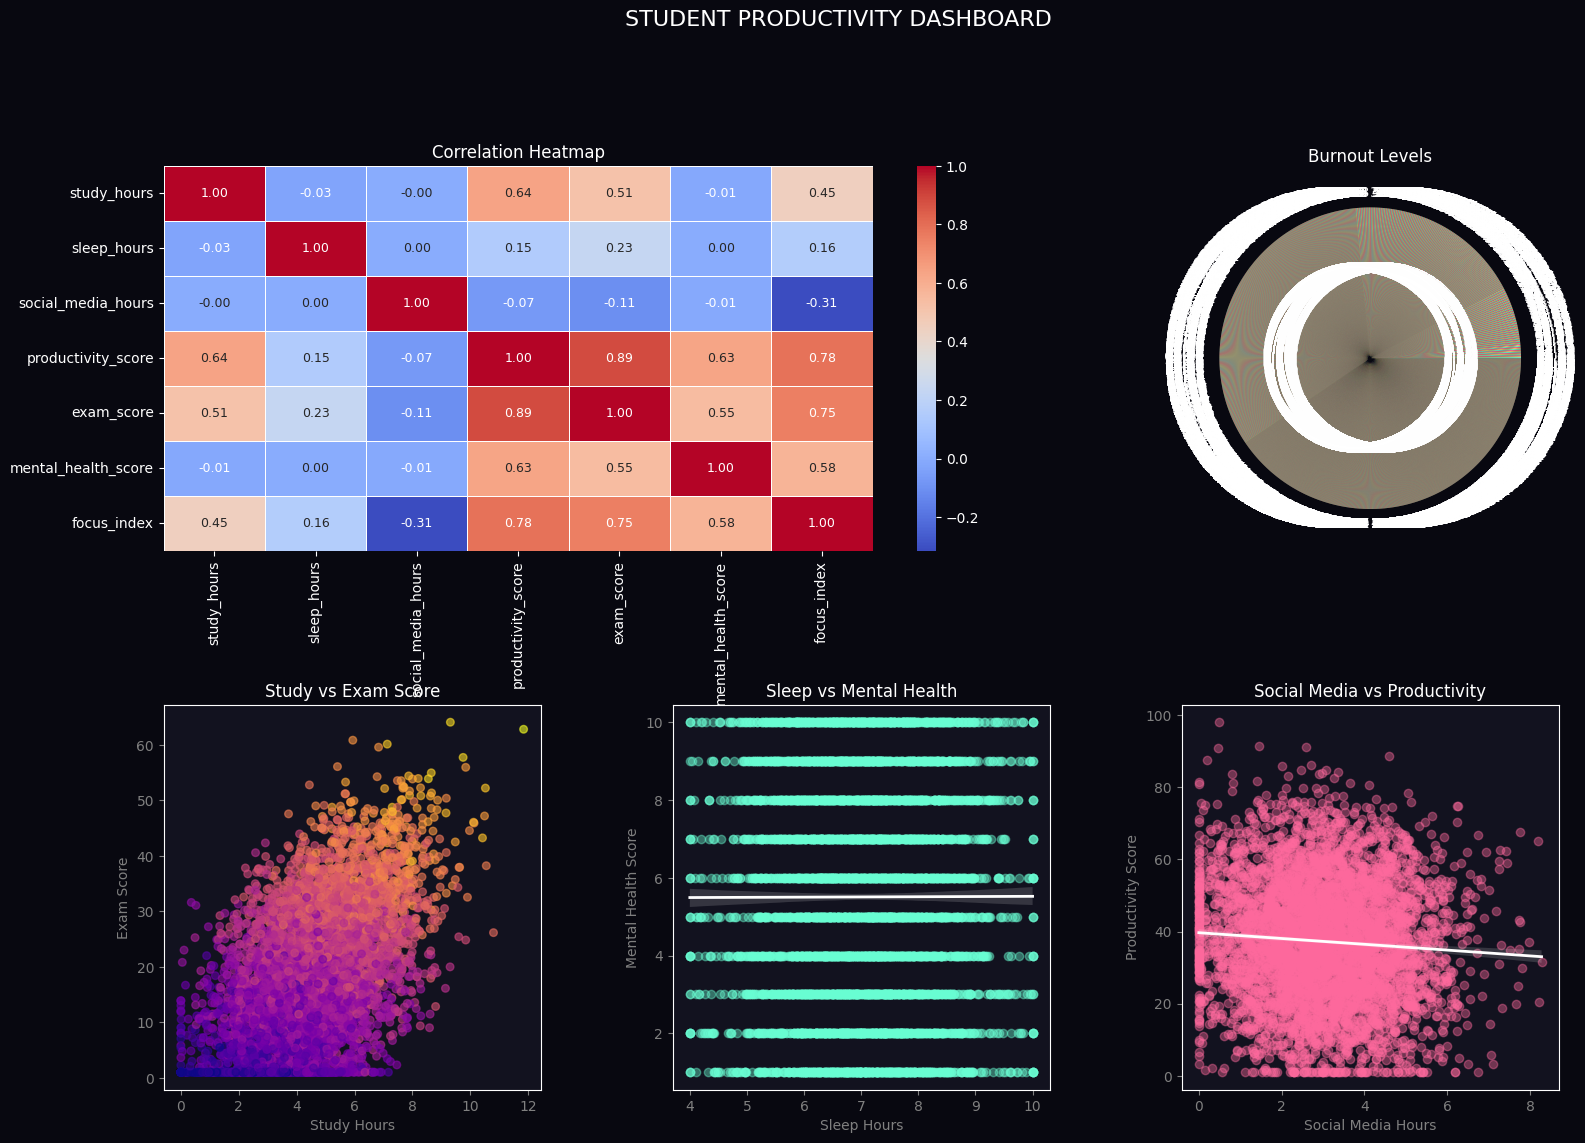

In [ ]:
fig = plt.figure(figsize=(18, 12), facecolor='#080810')
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1 - Heatmap
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#12121f')
num_cols = ['study_hours','sleep_hours','social_media_hours',
            'productivity_score','exam_score','mental_health_score','burnout_level'
            if 'burnout_level' not in df.select_dtypes(include=np.number).columns 
            else 'focus_index']
corr_small = df[['study_hours','sleep_hours','social_media_hours',
                 'productivity_score','exam_score','mental_health_score','focus_index']].corr()
sns.heatmap(corr_small, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax1, linewidths=0.5, annot_kws={'size': 9})
ax1.set_title('Correlation Heatmap', color='white', fontsize=12)

# Plot 2 - Burnout
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#12121f')
burnout_counts = df['burnout_level'].value_counts()
ax2.pie(burnout_counts, labels=burnout_counts.index,
        colors=['#6affd4','#ffd16a','#ff6a9e'],
        autopct='%1.1f%%', textprops={'color':'white'})
ax2.set_title('Burnout Levels', color='white', fontsize=12)

# Plot 3 - Scatter
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#12121f')
sc = ax3.scatter(df['study_hours'], df['exam_score'],
                 c=df['productivity_score'], cmap='plasma', alpha=0.6, s=30)
ax3.set_xlabel('Study Hours', color='gray')
ax3.set_ylabel('Exam Score', color='gray')
ax3.set_title('Study vs Exam Score', color='white', fontsize=12)
ax3.tick_params(colors='gray')

# Plot 4 - Sleep vs Mental Health
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#12121f')
sns.regplot(x='sleep_hours', y='mental_health_score', data=df, ax=ax4,
            scatter_kws={'alpha':0.4, 'color':'#6affd4'},
            line_kws={'color':'white', 'linewidth':2})
ax4.set_title('Sleep vs Mental Health', color='white', fontsize=12)
ax4.set_xlabel('Sleep Hours', color='gray')
ax4.set_ylabel('Mental Health Score', color='gray')
ax4.tick_params(colors='gray')

# Plot 5 - Social Media
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#12121f')
sns.regplot(x='social_media_hours', y='productivity_score', data=df, ax=ax5,
            scatter_kws={'alpha':0.4, 'color':'#ff6a9e'},
            line_kws={'color':'white', 'linewidth':2})
ax5.set_title('Social Media vs Productivity', color='white', fontsize=12)
ax5.set_xlabel('Social Media Hours', color='gray')
ax5.set_ylabel('Productivity Score', color='gray')
ax5.tick_params(colors='gray')
                                                   
plt.suptitle('STUDENT PRODUCTIVITY DASHBOARD', color='white', fontsize=16, y=1.01)
plt.savefig('../visualizations/dashboard.png', 
            dpi=150, 
            bbox_inches='tight',
            facecolor='#080810')
plt.show()